# Assignment 3: Speech Emotion Recognition
Vanshdeep Singh Sidhu | GitHub: vsidhu1002

Four classifiers, raw vs StandardScaler features, and evaluation on RAVDESS plus eight newly recorded personal clips. These recordings were made for this assignment; the prior recording assignment was not completed. Results below are actual runs, not inherited tutorial outputs.

## Reproduction
See README.md. Install requirements.txt and FFmpeg. Download/unzip the RAVDESS speech archive into `data/ravdess`; place eight labeled WAV files in `personal`. The included feature cache preserves the actual run. The split manifest records training/test files. Run from the repository root.

In [1]:
!python run_experiment.py --ravdess data/ravdess --personal personal --output results --jobs 4

Extracting 1440 RAVDESS samples
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    6.0s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    6.1s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:    6.2s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:    6.2s
[Parallel(n_jobs=4)]: Batch computation too fast (0.19350416620844274s.) Setting batch_size=2.
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    6.3s
[Parallel(n_jobs=4)]: Batch computation too fast (0.08554768562316895s.) Setting batch_size=4.
[Parallel(n_jobs=4)]: Done  48 tasks      | elapsed:    6.4s
[Parallel(n_jobs=4)]: Batch computation too fast (0.1602644920349121s.) Setting batch_size=8.
[Parallel(n_jobs=4)]: Done  92 tasks      | elapsed:    6.9s
[Parallel(n_jobs=4)]: Done 180 tasks      | elapsed:    7.8s
[Parallel(n_jobs=4)]: Done 284 tasks      | elapsed:    8.6s
[Parallel(n_jobs=4)]: Done 388 tasks      | elapsed:    9.4s

## All metrics
Precision, recall and F1 are macro averages over all eight classes. Scalers are fitted only on training data. No hyperparameters were chosen from test performance.

In [2]:
import pandas as pd
metrics = pd.read_csv('results/metrics.csv', keep_default_na=False)
print(metrics.to_string(index=False))

              model  scaling  dataset   n  accuracy  macro_precision  macro_recall  macro_f1  training_accuracy
            SVM RBF     None  RAVDESS 288  0.347222         0.297994      0.326333  0.267910           0.334201
            SVM RBF     None Personal   8  0.125000         0.017857      0.125000  0.031250           0.334201
            SVM RBF Standard  RAVDESS 288  0.531250         0.527027      0.511387  0.510556           0.757812
            SVM RBF Standard Personal   8  0.125000         0.015625      0.125000  0.027778           0.757812
                KNN     None  RAVDESS 288  0.482639         0.463049      0.472588  0.464115           1.000000
                KNN     None Personal   8  0.000000         0.000000      0.000000  0.000000           1.000000
                KNN Standard  RAVDESS 288  0.541667         0.549422      0.537534  0.531315           1.000000
                KNN Standard Personal   8  0.125000         0.017857      0.125000  0.031250           1

In [3]:
metrics = pd.read_csv('results/metrics.csv', keep_default_na=False)
print(metrics[metrics.dataset == 'Personal'][
    ['model', 'scaling', 'n', 'accuracy', 'macro_f1']
].to_string(index=False, float_format=lambda x: f'{x:.3f}'))

              model  scaling  n  accuracy  macro_f1
            SVM RBF     None  8     0.125     0.031
            SVM RBF Standard  8     0.125     0.028
                KNN     None  8     0.000     0.000
                KNN Standard  8     0.125     0.031
      Random Forest     None  8     0.375     0.258
      Random Forest Standard  8     0.250     0.188
Logistic Regression     None  8     0.125     0.062
Logistic Regression Standard  8     0.000     0.000


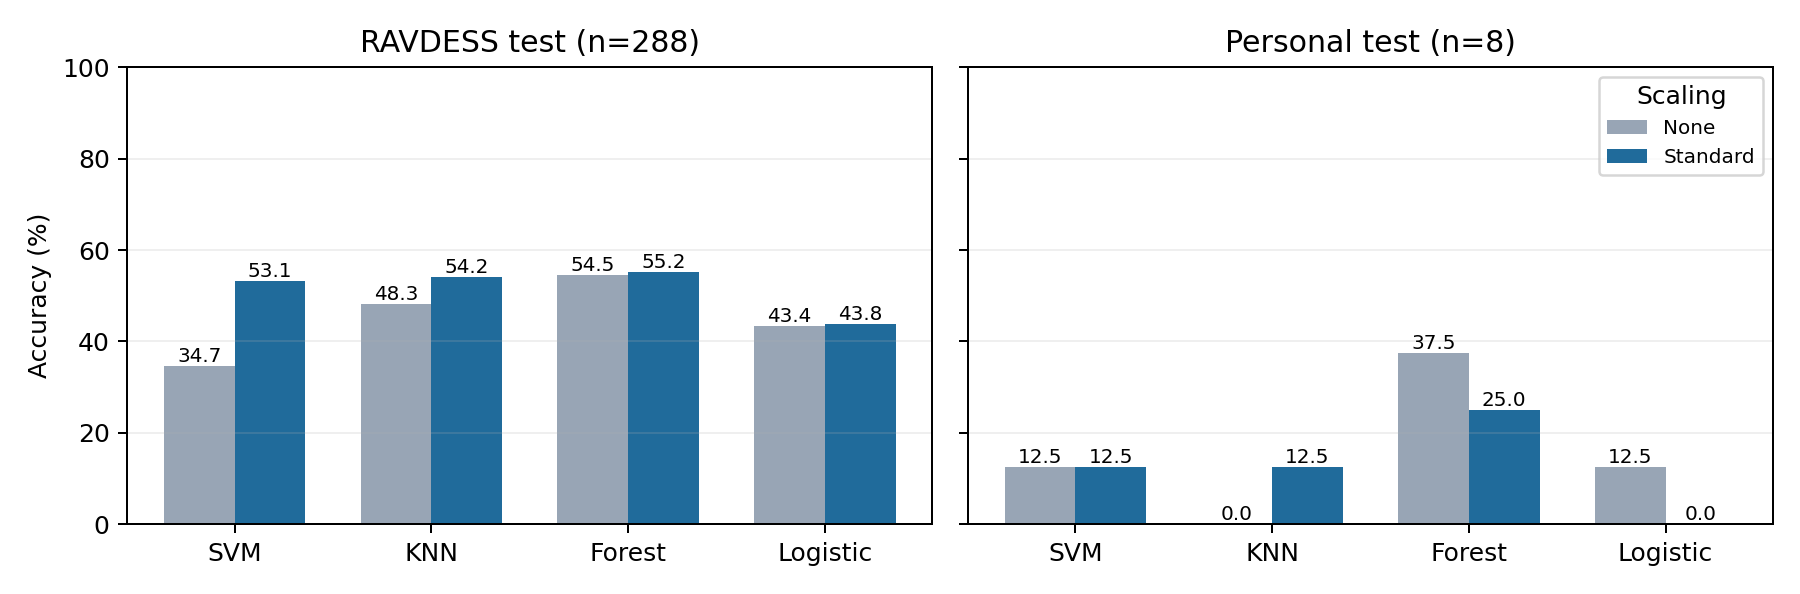

In [4]:
from IPython.display import display, Image
display(Image(filename='results/accuracy_comparison.png'))

## Feature distributions and personal predictions

In [5]:
print(pd.read_csv('results/feature_summary.csv').to_string(index=False))

 dataset  group           min        max       mean       std
 RAVDESS Chroma  3.177392e-01   0.865664   0.653990  0.081253
 RAVDESS    Mel  6.266326e-08 164.980225   0.186458  1.662568
 RAVDESS   MFCC -8.485936e+02  96.597054 -14.335766 93.772636
Personal Chroma  5.363738e-01   0.767484   0.626640  0.055994
Personal    Mel  9.385683e-06  33.272430   0.453636  2.047601
Personal   MFCC -4.857917e+02 122.802086  -9.117290 70.478638


In [6]:
print(pd.read_csv('results/personal_predictions.csv').to_string(index=False))

              model  scaling          file      true predicted
            SVM RBF      NaN     angry.wav     angry     angry
            SVM RBF      NaN      calm.wav      calm   disgust
            SVM RBF      NaN   disgust.wav   disgust     angry
            SVM RBF      NaN   fearful.wav   fearful     angry
            SVM RBF      NaN     happy.wav     happy     angry
            SVM RBF      NaN   neutral.wav   neutral     angry
            SVM RBF      NaN       sad.wav       sad     angry
            SVM RBF      NaN surprised.wav surprised     angry
            SVM RBF Standard     angry.wav     angry     angry
            SVM RBF Standard      calm.wav      calm     angry
            SVM RBF Standard   disgust.wav   disgust     angry
            SVM RBF Standard   fearful.wav   fearful     angry
            SVM RBF Standard     happy.wav     happy     angry
            SVM RBF Standard   neutral.wav   neutral     angry
            SVM RBF Standard       sad.wav       sad   

## Limitations
Only eight personal samples from one speaker: 12.5 percentage points per correct prediction. The stratified file-level RAVDESS split can share actors across train/test, so it is not speaker-independent. Unscaled logistic regression reached its 10,000-iteration cap; its result is provisional. Shared resampling at 22,050 Hz and a different split mean results do not exactly reproduce the tutorial. Tree scaling changes were small on RAVDESS and may reflect numerical threshold/tie differences. See the PDF report for interpretation and references.